# Algorytmika i matematyka uczenia maszynowego 
## Laboratorium 8

### Zadanie 1

1. Wczytaj plik `mieszkania.csv` za pomocą jednej z poniższych bibliotek:
   - [`pandas`](https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html) – funkcja `read_csv`,
   - [`numpy`](https://numpy.org/doc/stable/reference/generated/numpy.genfromtxt.html) – funkcja `genfromtxt`,
   - [`csv`](https://docs.python.org/3/library/csv.html) – funkcja `reader`.

2. Usuń nieprawidłowe dane, np. wiersze zawierające wartość `-` lub cenę równą `0`.

3. Zamień wartości liczbowe zapisane jako tekst na odpowiedni typ liczbowy.

4. Przedstaw **funkcję masy prawdopodobieństwa** wartości mieszkań w zależności od rodzaju *transakcji rynkowej*.  
   **Podpowiedź:** Skorzystaj z funkcji `displot` z biblioteki `seaborn` (jeśli nie masz biblioteki, zainstaluj ją poleceniem `pip install seaborn`).  
   Zwróć uwagę na argumenty: `x`, `hue`, `kind`, `fill`.

5. Wyświetl wszystkie trzy funkcje (dla ogółu, rynku pierwotnego i wtórnego) na jednym wykresie.

6. Zinterpretuj wyniki.

---

#### Informacje o zbiorze danych

- Dane dotyczą sprzedaży oraz cen nieruchomości i pochodzą z Głównego Urzędu Statystycznego (GUS), opracowane na podstawie danych z Rejestru Cen Nieruchomości (RCN), a do 31 lipca 2021 – z Rejestru Cen i Wartości Nieruchomości (RCiWN), prowadzonego przez starostwa powiatowe i prezydentów miast na prawach powiatu. Dane pochodzą z aktów notarialnych.
- Uwzględniono wyłącznie transakcje kupna/sprzedaży lokali mieszkalnych w budynkach wielorodzinnych (nie dotyczy domów jednorodzinnych), które miały miejsce w analizowanym okresie i zostały zarejestrowane w RCN przed datą przekazania danych do GUS.
- Dane dotyczą wyłącznie transakcji rynkowych, tj. sprzedaży na wolnym rynku (z wyłączeniem np. sprzedaży między osobami spokrewnionymi) oraz sprzedaży przetargowej.
- Podział na rynek pierwotny i wtórny:
  - **Rynek pierwotny**: sprzedaż na wolnym rynku przez osoby prawne, gdzie średnia cena 1 m² wynosi co najmniej 2 000 zł.
  - **Rynek wtórny**: pozostałe transakcje rynkowe, w tym sprzedaż przetargowa.
- W grudniu 2021 roku uzupełniono bazę BDL o dane za lata 2010–2014, obejmujące większą liczbę transakcji niż wcześniej publikowane dane.
- Brak danych od 2020 roku dla miasta Koszalin oraz częściowe braki dla Szczecina.

#### Oznaczenia w danych:

- `-` – brak informacji z powodu zmiany poziomu prezentacji, zmian w jednostkach terytorialnych lub cechach raportu,
- `n` – dane jeszcze niedostępne,
- `x` – brak informacji z powodu tajemnicy statystycznej lub niecelowości wypełnienia,
- `X` – brak danych ze względu na zmiany metodologiczne lub tajemnicę statystyczną.


d:\anaconda\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


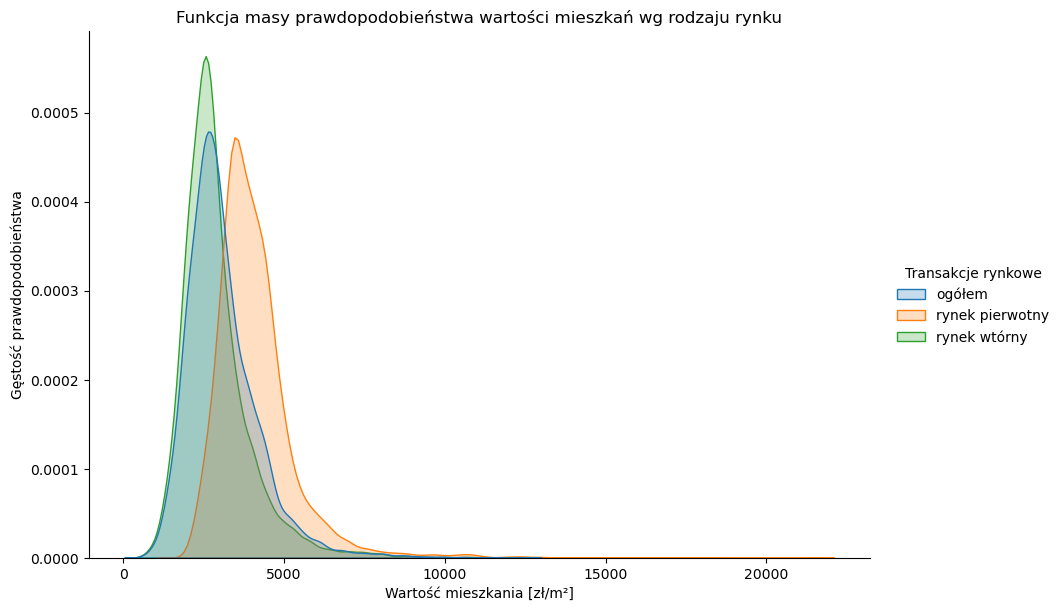

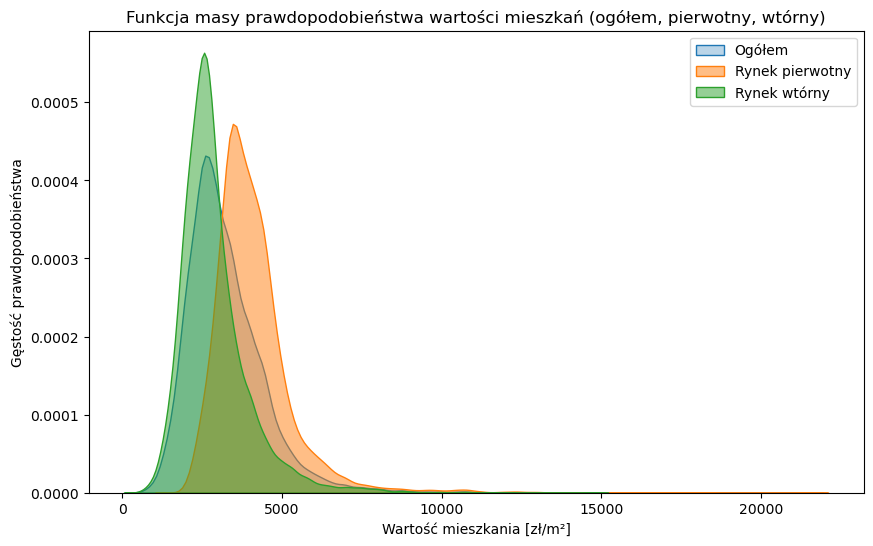

In [39]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

file_path = 'mieszkania.csv'
data = pd.read_csv(file_path, sep=';', encoding='utf-8')

data = data.replace(['-', 'n', 'x', 'X'], np.nan)
data = data.dropna()
data = data[data['Wartosc'] != '0']

data['Wartosc'] = data['Wartosc'].astype(int)

sns.displot(data=data, x='Wartosc', hue='Transakcje rynkowe', kind='kde', fill=True, common_norm=False, height=6, aspect=1.5)
plt.title('Funkcja masy prawdopodobieństwa wartości mieszkań wg rodzaju rynku')
plt.xlabel('Wartość mieszkania [zł/m²]')
plt.ylabel('Gęstość prawdopodobieństwa')
plt.show()

plt.figure(figsize=(10, 6))
sns.kdeplot(data=data, x='Wartosc', label='Ogółem', fill=True, alpha=0.3)
sns.kdeplot(data=data[data['Transakcje rynkowe'] == 'rynek pierwotny'], x='Wartosc', label='Rynek pierwotny', fill=True, alpha=0.5)
sns.kdeplot(data=data[data['Transakcje rynkowe'] == 'rynek wtórny'], x='Wartosc', label='Rynek wtórny', fill=True, alpha=0.5)
plt.title('Funkcja masy prawdopodobieństwa wartości mieszkań (ogółem, pierwotny, wtórny)')
plt.xlabel('Wartość mieszkania [zł/m²]')
plt.ylabel('Gęstość prawdopodobieństwa')
plt.legend()
plt.show()

### Zadanie 2 (kontynuacja poprzedniego)

1. Wyświetl dystrybuantę (empiryczną funkcję rozkładu) wartości mieszkań dla rodzaju transakcji `ogólny`.  
   **Podpowiedź:** Skorzystaj z funkcji `ecdfplot` z biblioteki `seaborn`.

2. Na podstawie wykresu oszacuj, jaki procent mieszkań sprzedawanych jest poniżej ceny 4 000 zł za m².


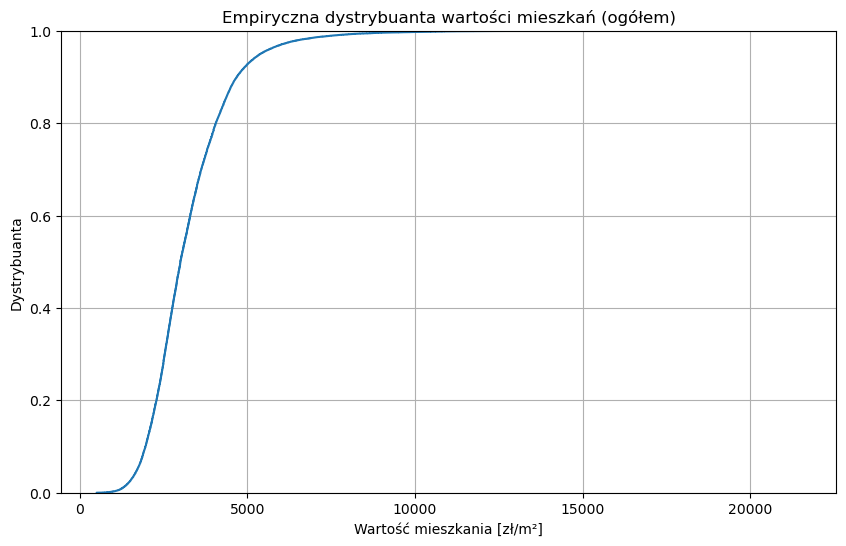

Około 78.6% mieszkań sprzedano poniżej 4000 zł/m².


In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.ecdfplot(data=data, x='Wartosc')
plt.title('Empiryczna dystrybuanta wartości mieszkań (ogółem)')
plt.xlabel('Wartość mieszkania [zł/m²]')
plt.ylabel('Dystrybuanta')
plt.grid(True)
plt.show()

procent_ponizej_4000 = (data['Wartosc'] < 4000).mean() * 100
print(f"Około {procent_ponizej_4000:.1f}% mieszkań sprzedano poniżej 4000 zł/m².")

### Zadanie 3

Opis zbioru danych znajduje się w pliku `boston.txt`.

1. Wczytaj plik `boston.txt` (zwróć uwagę na jego format).  
   **Podpowiedź:** Skorzystaj z funkcji `read_csv` z biblioteki `pandas`, używając odpowiednich parametrów: `skiprows`, `header`, `sep`.  
   
   > Uwaga: Nie modyfikuj zawartości pliku.

2. Wyświetl funkcję masy prawdopodobieństwa dla cen mieszkań (`MEDV`).

3. Wyświetl funkcję masy prawdopodobieństwa z dwiema zmiennymi: `MEDV` (cena) i `RM` (liczba pokoi).  
   - Dla jakiej ceny i liczby pokoi sprzedaje się najwięcej mieszkań?  
   - Jakie inne informacje można wyczytać z wykresu?

4. Przeanalizuj dowolny dodatkowy atrybut i krótko opisz uzyskane wyniki.


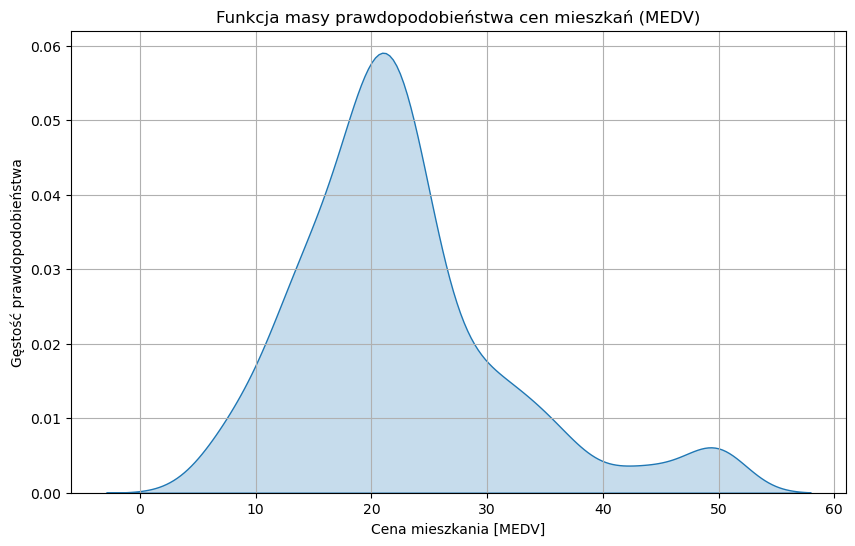

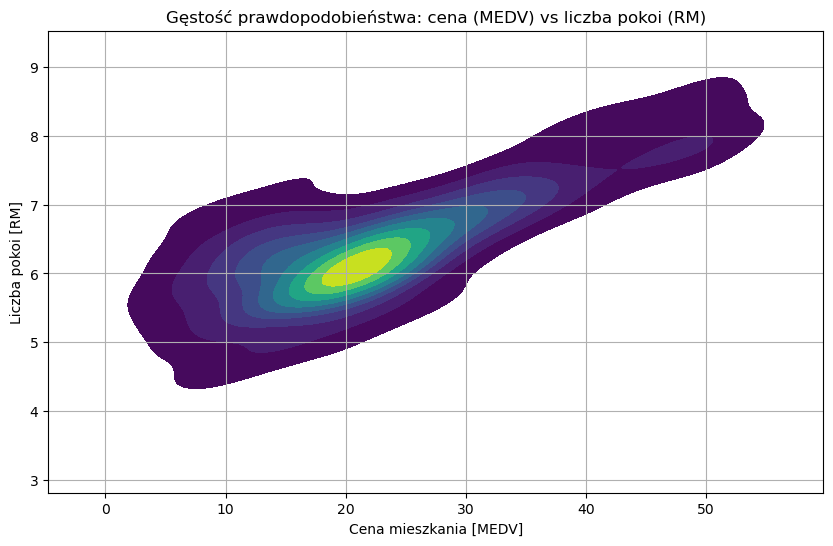

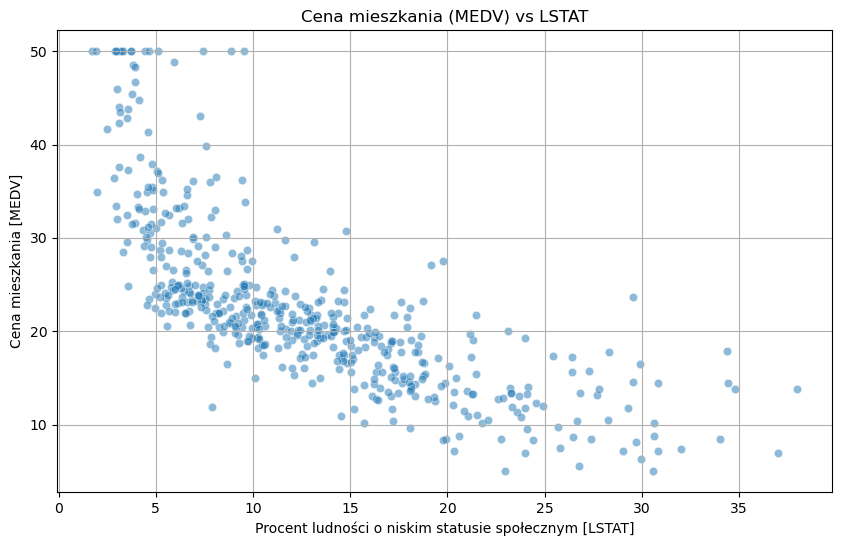

Widać, że wyższy procent ludności o niskim statusie społecznym (LSTAT) wiąże się z niższą ceną mieszkań (MEDV).


In [41]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

with open('boston.txt', encoding='utf-8') as f:
    lines = f.readlines()[22:]

rows = []
for i in range(0, len(lines), 2):
    line = lines[i].strip() + " " + lines[i+1].strip()
    rows.append(line)

data = [row.split() for row in rows]
boston = pd.DataFrame(data, columns=[
    'CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
    'PTRATIO', 'B', 'LSTAT', 'MEDV'
])
boston = boston.astype(float)

plt.figure(figsize=(10, 6))
sns.kdeplot(data=boston, x='MEDV', fill=True)
plt.title('Funkcja masy prawdopodobieństwa cen mieszkań (MEDV)')
plt.xlabel('Cena mieszkania [MEDV]')
plt.ylabel('Gęstość prawdopodobieństwa')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
sns.kdeplot(
    data=boston, x='MEDV', y='RM', fill=True, cmap='viridis', thresh=0.05
)
plt.title('Gęstość prawdopodobieństwa: cena (MEDV) vs liczba pokoi (RM)')
plt.xlabel('Cena mieszkania [MEDV]')
plt.ylabel('Liczba pokoi [RM]')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=boston, x='LSTAT', y='MEDV', alpha=0.5)
plt.title('Cena mieszkania (MEDV) vs LSTAT')
plt.xlabel('Procent ludności o niskim statusie społecznym [LSTAT]')
plt.ylabel('Cena mieszkania [MEDV]')
plt.grid(True)
plt.show()

print("Widać, że wyższy procent ludności o niskim statusie społecznym (LSTAT) wiąże się z niższą ceną mieszkań (MEDV).")